In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Define the file paths
general_file_path = '/content/drive/My Drive/Tiruppur_Data/Ground_Water_General.csv'
water_level_file_path = '/content/drive/My Drive/Tiruppur_Data/Ground_Water_Level.csv'

# 3. Load the datasets into pandas DataFrames
try:
    general_df = pd.read_csv(general_file_path)
    level_df = pd.read_csv(water_level_file_path)
    print("Files loaded successfully!")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nPlease double-check your file paths. Make sure the folder and file names are correct.")

# 4. Display the first few rows of each DataFrame to verify
print("\n--- General Well Information ---")
print(general_df.head())

print("\n--- Water Level Data ---")
print(level_df.head())

print("\n--- Info for General Data ---")
general_df.info()

print("\n--- Info for General Data ---")
level_df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files loaded successfully!

--- General Well Information ---
  Well No Type Well Type           Agency  State     District Tahsil / Taluk  \
0   53258   OB  Dug Well  WRD, Tamil Nadu     22  19.Tiruppur       Uthukuli   
1   53260   OB  Dug Well  WRD, Tamil Nadu     22  19.Tiruppur       Uthukuli   
2   53261   OB  Dug Well  WRD, Tamil Nadu     22  19.Tiruppur       Uthukuli   
3   53262   OB  Dug Well  WRD, Tamil Nadu     22  19.Tiruppur       Uthukuli   
4   53271   OB  Dug Well  WRD, Tamil Nadu     22  19.Tiruppur       Uthukuli   

  Block / Mandal              Village Hamlet  ... DWLR installed DWLR No  \
0       Uthukuli         Chengappalli    NaN  ...          False     NaN   
1       Uthukuli         Rettipalayam    NaN  ...          False     NaN   
2       Uthukuli   Sar. Periyapalayam    NaN  ...          False     NaN   
3       Uthukuli  Puthur 

In [ ]:
# Import necessary libraries for analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## --- Inspect Water Level Data ---
print("--- Water Level Data Info ---")
level_df.info()

# The 'Water Level (m)' column is of 'object' type because it contains text like 'dry'.
# Let's convert it to a numeric type. 'coerce' will turn non-numeric values into NaN (Not a Number).
level_df['Water Level (m)'] = pd.to_numeric(level_df['Water Level (m)'], errors='coerce')

# The 'date' column should be a datetime object for time series analysis.
level_df['date'] = pd.to_datetime(level_df['date'], format='%d-%m-%Y')

print("\n--- Corrected Water Level Data Info ---")
level_df.info()

## --- Inspect General Well Data ---
print("\n--- General Well Data Info ---")
general_df.info()


## --- Merge the Datasets ---
# We'll merge the two DataFrames on the 'Well No' column to combine all information.
# An 'inner' merge keeps only the wells present in both datasets.
df = pd.merge(level_df, general_df, on='Well No', how='inner')

print(f"\nShape of the merged DataFrame: {df.shape}")
print("Merged DataFrame head:")
print(df.head())


## --- Handle Missing Values ---
print("\n--- Missing Values in Merged DataFrame ---")
# Let's count missing values in each column
print(df.isnull().sum())

--- Water Level Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11644 entries, 0 to 11643
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Well No          11644 non-null  object 
 1   Type             11644 non-null  object 
 2   date             11644 non-null  object 
 3   time             0 non-null      float64
 4   Ht of Ms Pt      11303 non-null  float64
 5   Water Level (m)  10328 non-null  float64
 6   Remarks          2510 non-null   object 
 7   Flag             312 non-null    object 
dtypes: float64(3), object(5)
memory usage: 727.9+ KB

--- Corrected Water Level Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11644 entries, 0 to 11643
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Well No          11644 non-null  object        
 1   Type             11644 non-null  ob

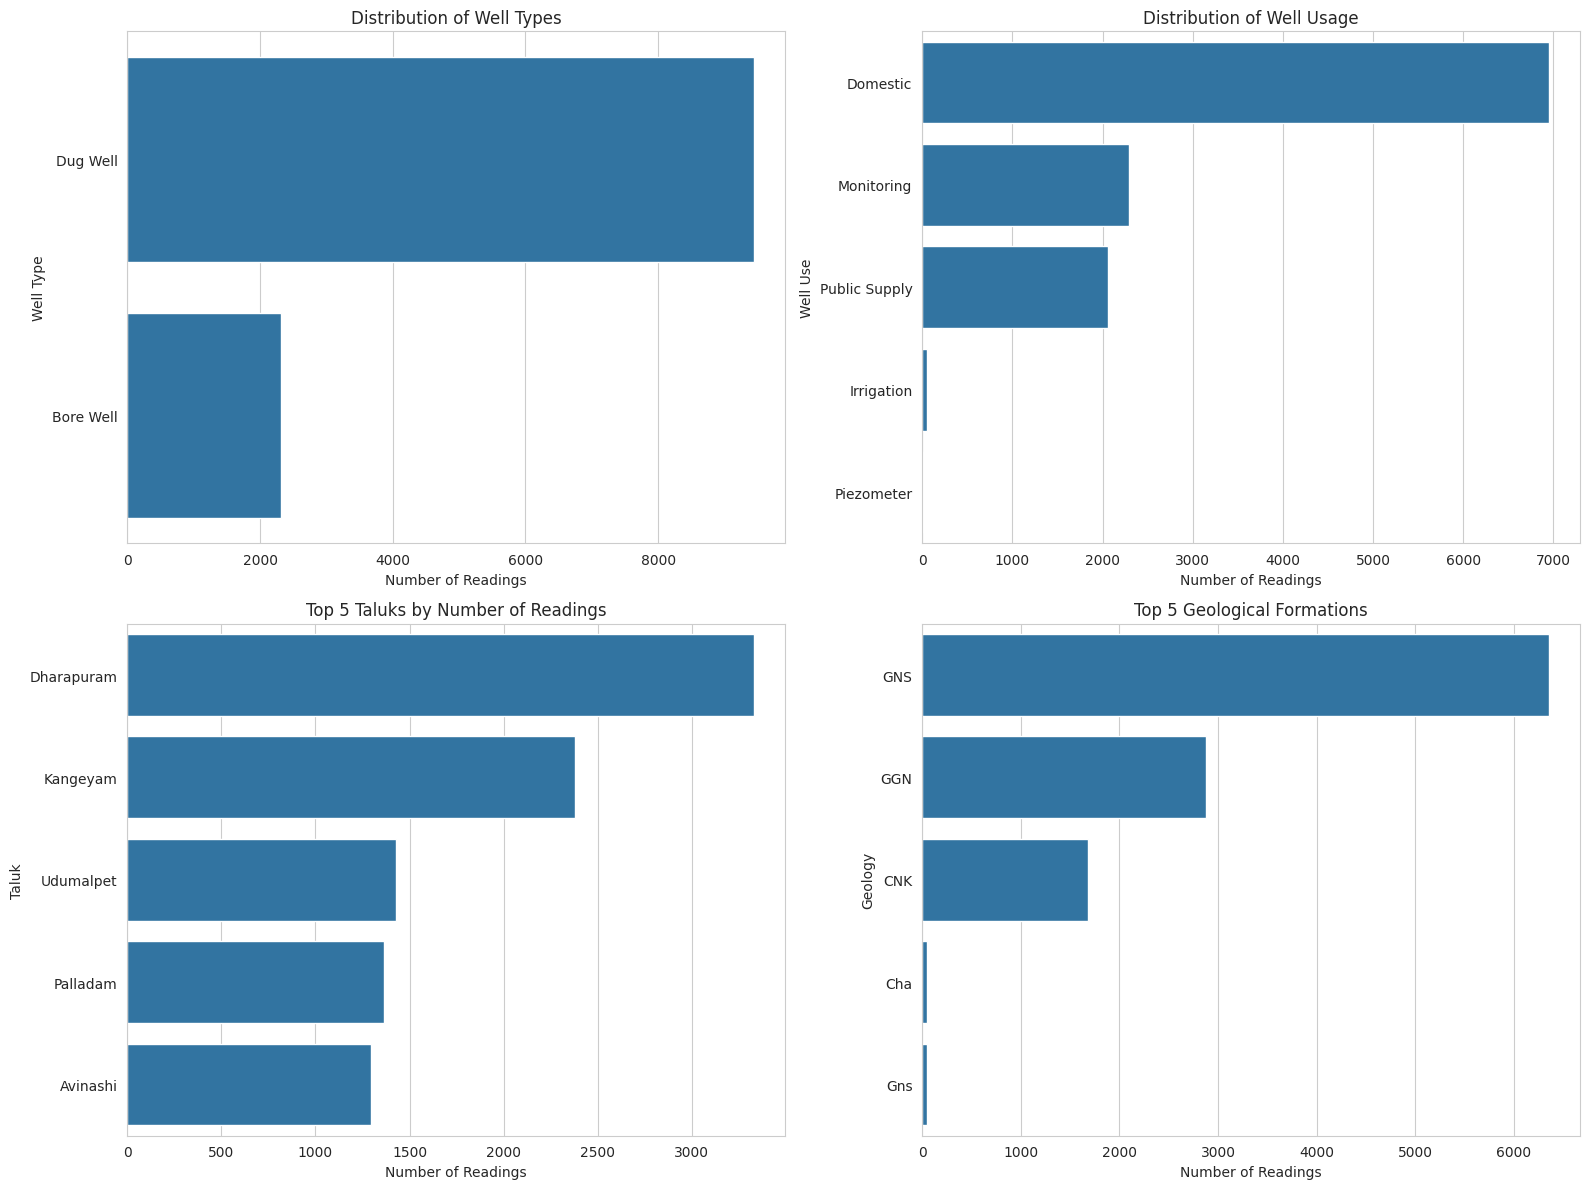

In [ ]:
# Set up a figure for multiple plots
plt.figure(figsize=(16, 12))

# Plot 1: Well Type Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, y='Well Type', order=df['Well Type'].value_counts().index)
plt.title('Distribution of Well Types')
plt.xlabel('Number of Readings')
plt.ylabel('Well Type')

# Plot 2: Well Usage Distribution
plt.subplot(2, 2, 2)
sns.countplot(data=df, y='Well use', order=df['Well use'].value_counts().index)
plt.title('Distribution of Well Usage')
plt.xlabel('Number of Readings')
plt.ylabel('Well Use')

# Plot 3: Distribution by Taluk (Top 5 for clarity)
plt.subplot(2, 2, 3)
top_5_taluks = df['Tahsil / Taluk'].value_counts().nlargest(5).index
sns.countplot(data=df[df['Tahsil / Taluk'].isin(top_5_taluks)], y='Tahsil / Taluk', order=top_5_taluks)
plt.title('Top 5 Taluks by Number of Readings')
plt.xlabel('Number of Readings')
plt.ylabel('Taluk')

# Plot 4: Geology Distribution (Top 5 for clarity)
plt.subplot(2, 2, 4)
top_5_geology = df['Geology'].value_counts().nlargest(5).index
sns.countplot(data=df[df['Geology'].isin(top_5_geology)], y='Geology', order=top_5_geology)
plt.title('Top 5 Geological Formations')
plt.xlabel('Number of Readings')
plt.ylabel('Geology')

plt.tight_layout()
plt.show()

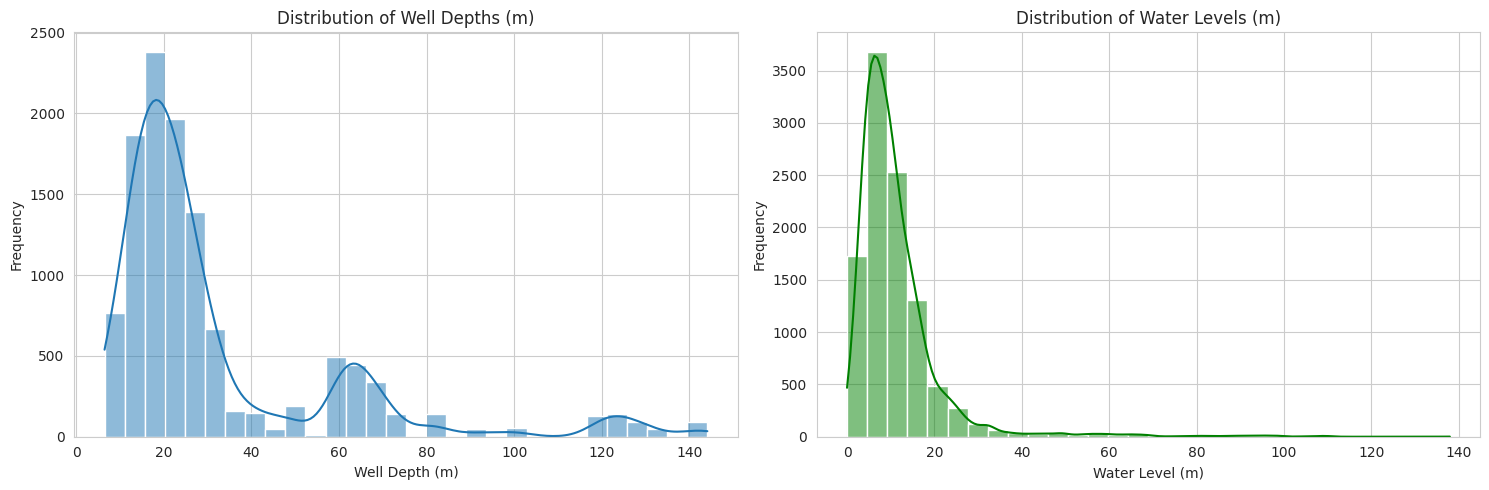

In [ ]:
# Set up a figure for multiple plots
plt.figure(figsize=(15, 5))

# Plot 1: Distribution of Well Depth
plt.subplot(1, 2, 1)
sns.histplot(df['Well Depth '], bins=30, kde=True)
plt.title('Distribution of Well Depths (m)')
plt.xlabel('Well Depth (m)')
plt.ylabel('Frequency')

# Plot 2: Distribution of Water Levels
plt.subplot(1, 2, 2)
sns.histplot(df['Water Level (m)'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of Water Levels (m)')
plt.xlabel('Water Level (m)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

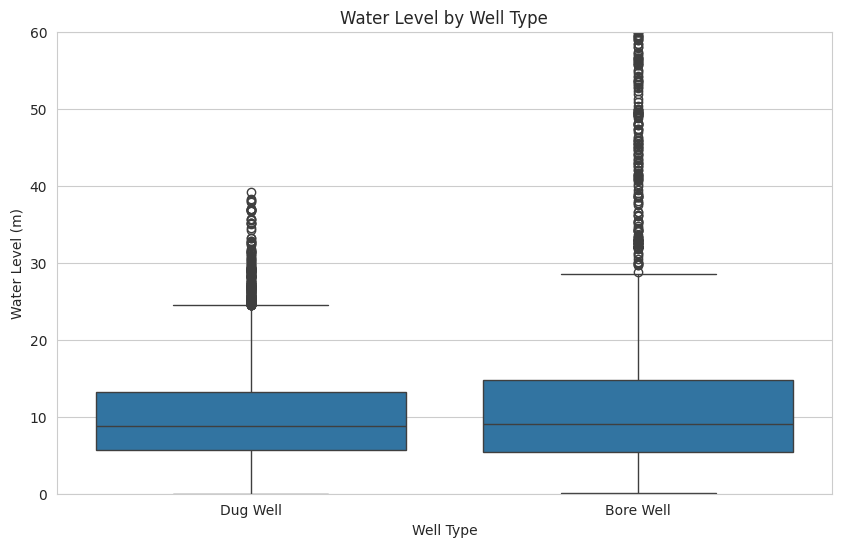

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Well Type', y='Water Level (m)')
plt.title('Water Level by Well Type')
plt.xlabel('Well Type')
plt.ylabel('Water Level (m)')
plt.ylim(0, 60) # Setting a y-limit to exclude extreme outliers for better visualization
plt.show()

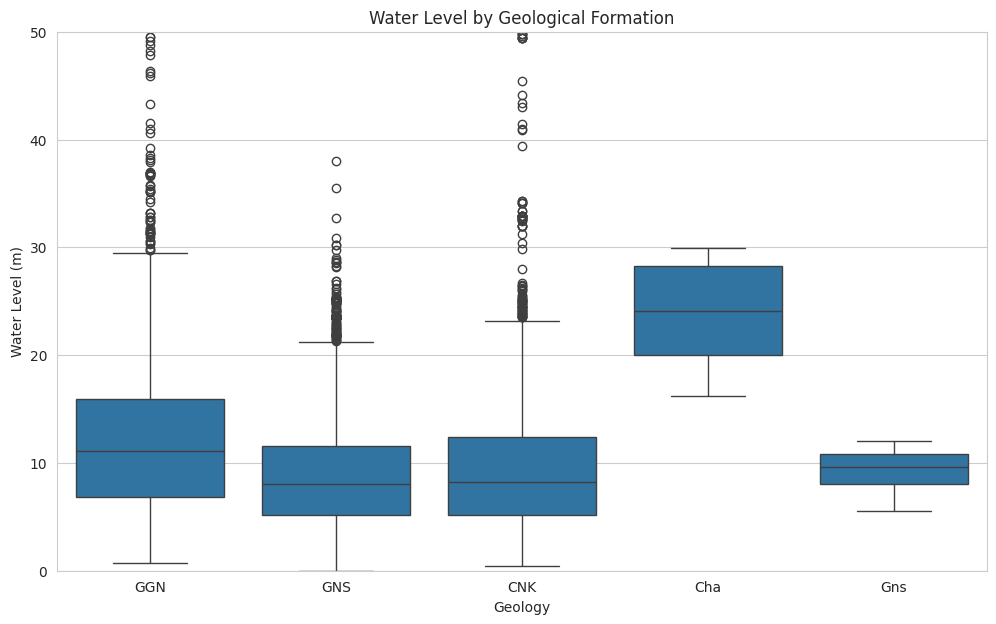

In [ ]:
plt.figure(figsize=(12, 7))
# We'll focus on the most common geological types for a clearer plot
top_geology = df['Geology'].value_counts().nlargest(5).index
sns.boxplot(data=df[df['Geology'].isin(top_geology)], x='Geology', y='Water Level (m)')
plt.title('Water Level by Geological Formation')
plt.xlabel('Geology')
plt.ylabel('Water Level (m)')
plt.ylim(0, 50)
plt.show()

/tmp/ipython-input-3562764764.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_wl = df_time['Water Level (m)'].resample('M').mean()


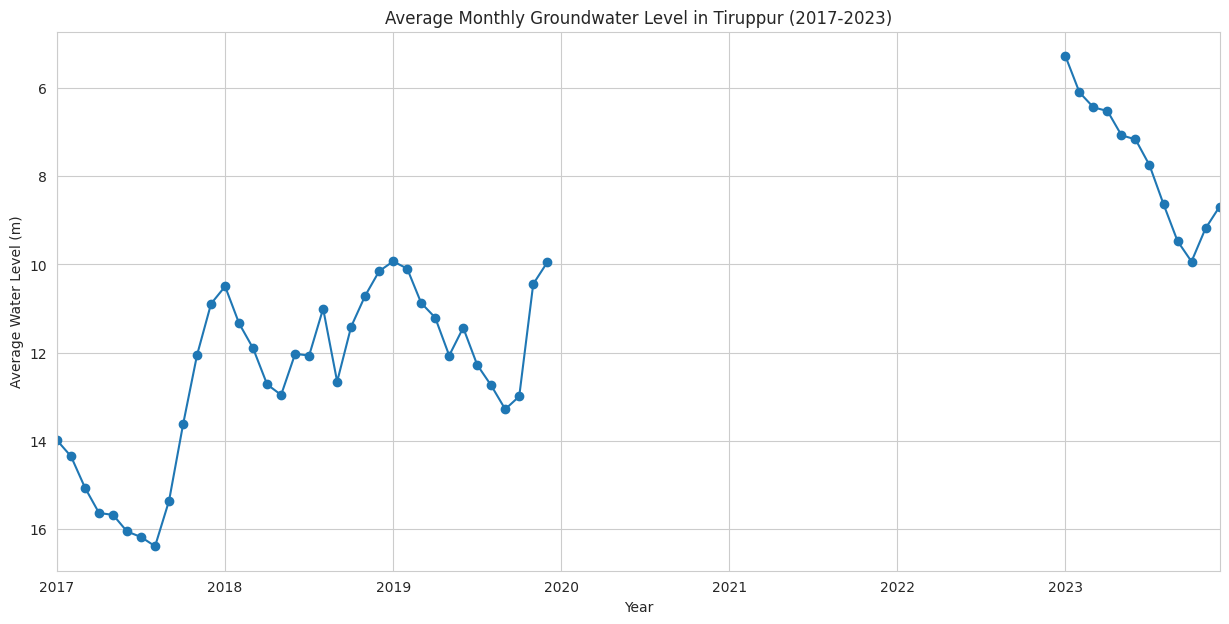

In [ ]:
# Set the date as the index for time-series plotting
df_time = df.set_index('date')

# Calculate the average monthly water level across all wells
monthly_avg_wl = df_time['Water Level (m)'].resample('M').mean()

# Plot the time series
plt.figure(figsize=(15, 7))
monthly_avg_wl.plot(marker='o', linestyle='-')
plt.title('Average Monthly Groundwater Level in Tiruppur (2017-2023)')
plt.xlabel('Year')
plt.ylabel('Average Water Level (m)')
plt.gca().invert_yaxis() # Invert y-axis: lower numbers mean more water (closer to surface)
plt.show()

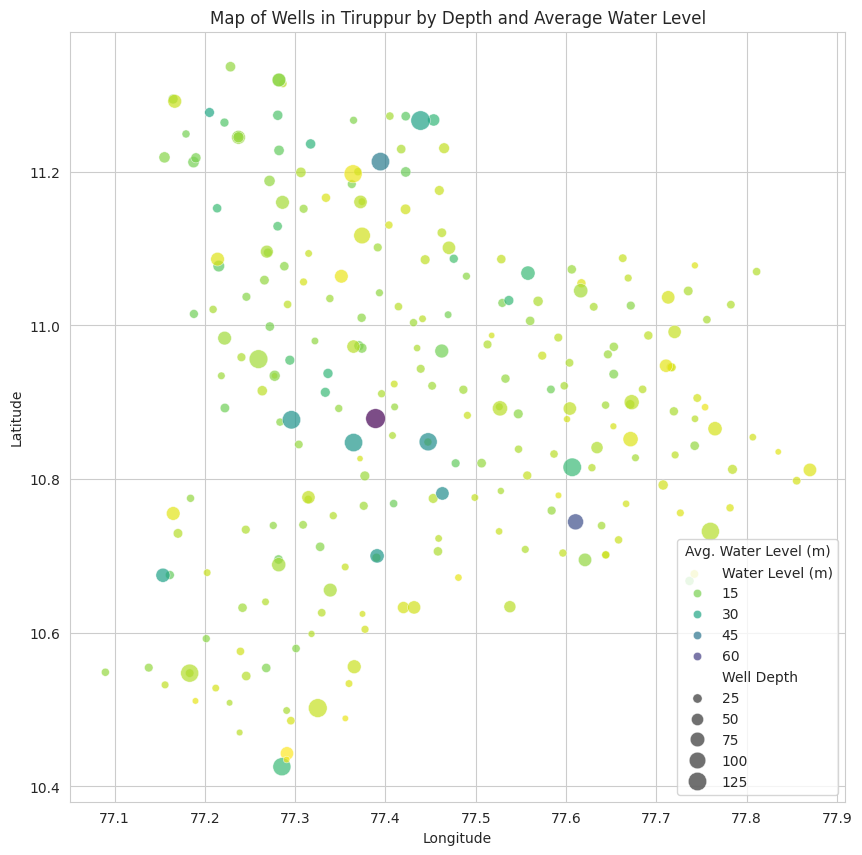

In [ ]:
plt.figure(figsize=(10, 10))

# Create a scatter plot using longitude and latitude
# We can color the dots based on the average water level for that well
avg_well_level = df.groupby('Well No')['Water Level (m)'].mean().reset_index()
map_df = pd.merge(general_df, avg_well_level, on='Well No')

sns.scatterplot(data=map_df, x='Longitude', y='Latitude', hue='Water Level (m)',
                palette='viridis_r', size='Well Depth ', sizes=(20, 200), alpha=0.7)

plt.title('Map of Wells in Tiruppur by Depth and Average Water Level')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Avg. Water Level (m)')
plt.show()

In [ ]:
from scipy.stats import ttest_ind

## --- Hypothesis Test 1: Water Level vs. Well Type ---

# 1. Create two separate data samples for each well type
# We drop missing values (.dropna()) to ensure the test runs correctly
dug_well_levels = df[df['Well Type'] == 'Dug Well']['Water Level (m)'].dropna()
bore_well_levels = df[df['Well Type'] == 'Bore Well']['Water Level (m)'].dropna()

# 2. Perform the two-sample t-test
# The 'equal_var=False' argument is used because the variances of the two groups might not be equal.
t_statistic, p_value = ttest_ind(dug_well_levels, bore_well_levels, equal_var=False)

# 3. Print the results and interpret them
print(f"--- T-Test Results: Dug Well vs. Bore Well Water Levels ---")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# 4. Make a conclusion based on the p-value
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: The p-value is less than 0.05.")
    print("We REJECT the null hypothesis.")
    print("✅ There is a statistically significant difference in the average water levels between Dug Wells and Bore Wells.")
else:
    print("\nConclusion: The p-value is greater than or equal to 0.05.")
    print("We FAIL to reject the null hypothesis.")
    print("❌ We do not have enough statistical evidence to say there is a significant difference between the two well types.")

--- T-Test Results: Dug Well vs. Bore Well Water Levels ---
T-statistic: -13.5213
P-value: 0.0000

Conclusion: The p-value is less than 0.05.
We REJECT the null hypothesis.
✅ There is a statistically significant difference in the average water levels between Dug Wells and Bore Wells.


In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## --- Hypothesis Test 2: Water Level vs. Taluk ---

# 1. Select the top 5 taluks to ensure we have enough data for a meaningful comparison
top_taluks = df['Tahsil / Taluk'].value_counts().nlargest(5).index
df_top_taluks = df[df['Tahsil / Taluk'].isin(top_taluks)]

# 2. Create a list of data samples for each taluk
groups = [
    df_top_taluks['Water Level (m)'][df_top_taluks['Tahsil / Taluk'] == taluk].dropna()
    for taluk in top_taluks
]

# 3. Perform the ANOVA test
f_statistic, p_value = f_oneway(*groups)

# 4. Print the results and interpret them
print(f"--- ANOVA Results: Water Levels across Top 5 Taluks ---")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# 5. Make a conclusion and run a post-hoc test if significant
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: The p-value is less than 0.05.")
    print("We REJECT the null hypothesis.")
    print("✅ There is a statistically significant difference in water levels among the taluks.")

    print("\n--- Tukey's HSD Post-Hoc Test: Identifying which pairs are different ---")
    # Perform Tukey's HSD test to see which specific pairs of taluks are different
    tukey_results = pairwise_tukeyhsd(
        endog=df_top_taluks['Water Level (m)'],
        groups=df_top_taluks['Tahsil / Taluk'],
        alpha=alpha
    )
    print(tukey_results)
    print("\nInterpretation of Tukey's Test:")
    print("The table above shows pairwise comparisons. If 'reject' is True for a pair,")
    print("it means their average water levels are significantly different from each other.")

else:
    print("\nConclusion: The p-value is greater than or equal to 0.05.")
    print("We FAIL to reject the null hypothesis.")
    print("❌ We do not have enough statistical evidence to say there is a significant difference in water levels among the taluks.")

--- ANOVA Results: Water Levels across Top 5 Taluks ---
F-statistic: 62.6874
P-value: 0.0000

Conclusion: The p-value is less than 0.05.
We REJECT the null hypothesis.
✅ There is a statistically significant difference in water levels among the taluks.

--- Tukey's HSD Post-Hoc Test: Identifying which pairs are different ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1     group2   meandiff p-adj lower upper reject
-------------------------------------------------------
  Avinashi Dharapuram      nan   nan   nan   nan  False
  Avinashi   Kangeyam      nan   nan   nan   nan  False
  Avinashi   Palladam      nan   nan   nan   nan  False
  Avinashi  Udumalpet      nan   nan   nan   nan  False
Dharapuram   Kangeyam      nan   nan   nan   nan  False
Dharapuram   Palladam      nan   nan   nan   nan  False
Dharapuram  Udumalpet      nan   nan   nan   nan  False
  Kangeyam   Palladam      nan   nan   nan   nan  False
  Kangeyam  Udumalpet      nan   nan   nan   nan  False
  

In [ ]:
# --- Sort data for time-series operations ---
# It's crucial to sort by well and then by date before creating lag/rolling features.
df.sort_values(by=['Well No', 'date'], inplace=True)

# --- 1. Time-Based Features ---
print("Creating time-based features (year, month)...")
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# --- 2. Lag Features ---
# This creates a new column with the water level from the previous month for each well.
# This is often the single most important predictor.
print("Creating lag features (previous month's water level)...")
# We use .groupby('Well No') to ensure the lag is calculated independently for each well.
df['wl_lag_1'] = df.groupby('Well No')['Water Level (m)'].shift(1)

# --- 3. Rolling Window Features ---
# This calculates the average water level of the previous 3 months for each well.
# It helps the model understand the recent trend and smooths out noise.
print("Creating rolling window features (3-month rolling average)...")
# .transform() applies the function to each group and returns a result of the same shape.
# .shift(1) ensures we only use past data to calculate the average, preventing data leakage.
df['wl_rolling_mean_3'] = df.groupby('Well No')['Water Level (m)'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# --- 4. Clean up the DataFrame ---
# The lag and rolling features created NaN values for the first few entries of each well.
# We'll drop these rows to create a clean dataset ready for modeling.
print(f"\nShape before dropping NaNs: {df.shape}")
df_model = df.dropna(subset=['Water Level (m)', 'wl_lag_1', 'wl_rolling_mean_3'])
print(f"Shape after dropping NaNs: {df_model.shape}")

# --- 5. Display the results ---
print("\n--- DataFrame with New Features (tail end) ---")
# We show the tail to see the calculated lag and rolling mean values.
print(df_model[['Well No', 'date', 'Water Level (m)', 'year', 'month', 'wl_lag_1', 'wl_rolling_mean_3']].tail(10))

Creating time-based features (year, month)...
Creating lag features (previous month's water level)...
Creating rolling window features (3-month rolling average)...

Shape before dropping NaNs: (11753, 54)
Shape after dropping NaNs: (10109, 54)

--- DataFrame with New Features (tail end) ---
        Well No       date  Water Level (m)  year  month  wl_lag_1  \
9365   MWSETR15 2023-03-03             6.08  2023      3      4.82   
9592   MWSETR15 2023-04-05             6.67  2023      4      6.08   
9828   MWSETR15 2023-05-03            25.30  2023      5      6.67   
10082  MWSETR15 2023-06-03            25.30  2023      6     25.30   
10332  MWSETR15 2023-07-06            15.30  2023      7     25.30   
10513  MWSETR15 2023-08-01            22.08  2023      8     15.30   
10760  MWSETR15 2023-09-01            56.60  2023      9     22.08   
11008  MWSETR15 2023-10-03            56.88  2023     10     56.60   
11256  MWSETR15 2023-11-01            48.04  2023     11     56.88   
11506  M

--- Splitting Data ---
Training set shape: (4763, 8)
Testing set shape: (5346, 8)

--- Training Random Forest Model ---
Model training complete.

--- Evaluating Model Performance ---
R-squared (R²): 0.7910
Mean Absolute Error (MAE): 1.6028 m

Interpretation:
- R²: The model explains approximately 79.1% of the variance in the test data.
- MAE: On average, the model's prediction is off by about 1.60 meters.


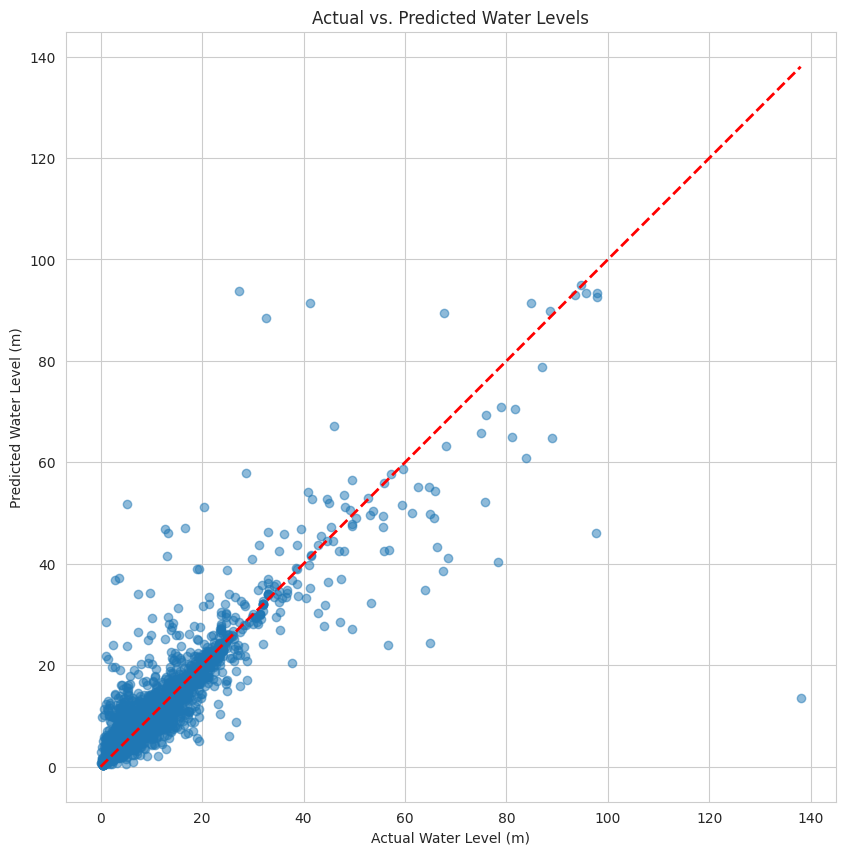


--- Feature Importance ---
              feature  importance
5            wl_lag_1    0.843774
6   wl_rolling_mean_3    0.121873
4         Well Depth     0.011299
1               month    0.010392
3           Longitude    0.005791
2            Latitude    0.005269
0                year    0.001053
7  Well Type_Dug Well    0.000549


/tmp/ipython-input-4211753031.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')


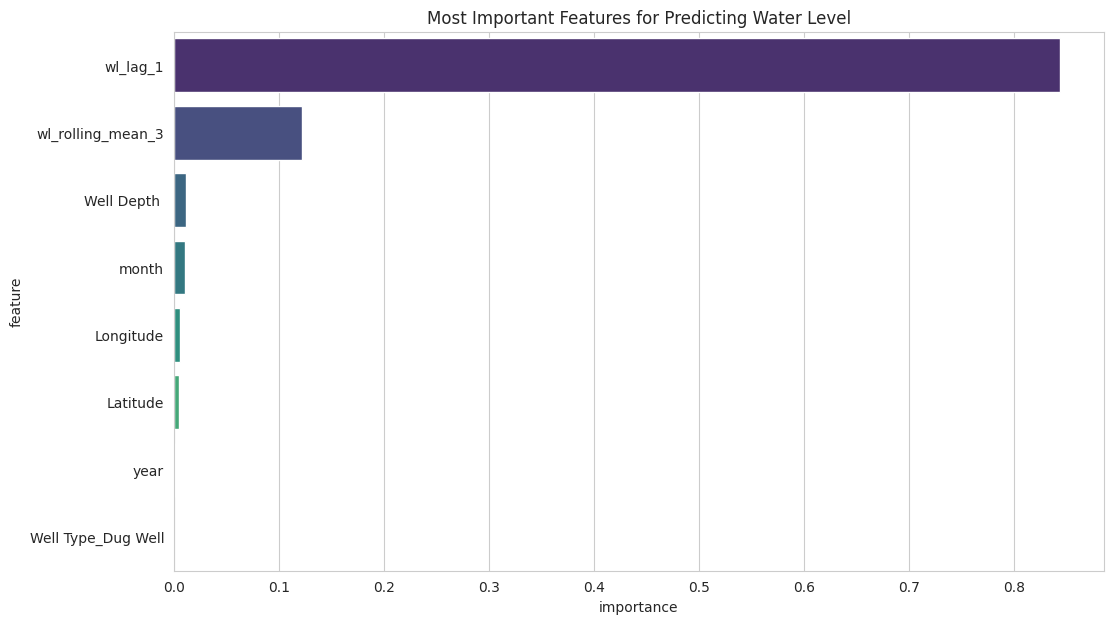

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Features (X) and Target (y) ---

# We need to convert categorical columns like 'Well Type' into a numeric format.
# One-hot encoding creates a new column for each category (e.g., 'Well Type_Dug Well').
# 'drop_first=True' drops one of the new columns to avoid redundancy.
df_final = pd.get_dummies(df_model, columns=['Well Type'], drop_first=True)


# Select the columns we'll use as predictors
features = [
    'year',
    'month',
    'Latitude',
    'Longitude',
    'Well Depth ',
    'wl_lag_1',
    'wl_rolling_mean_3',
    # Use the name of the new dummy variable column instead of the original 'Well Type'
    'Well Type_Dug Well' # Or 'Well Type_Bore Well' depending on alphabetical order
]

X = df_final[features]
y = df_final['Water Level (m)']

# --- 2. Split Data into Training and Testing Sets (Time-Based Split) ---
print("--- Splitting Data ---")
train_end_date = '2018-12-31'

X_train = df_final[df_final['date'] <= train_end_date][features]
y_train = df_final[df_final['date'] <= train_end_date]['Water Level (m)']

X_test = df_final[df_final['date'] > train_end_date][features]
y_test = df_final[df_final['date'] > train_end_date]['Water Level (m)']

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


# --- 3. Train the Random Forest Model ---
print("\n--- Training Random Forest Model ---")
# n_estimators: number of trees in the forest.
# random_state: ensures results are reproducible.
# n_jobs=-1: uses all available CPU cores for faster training.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model.fit(X_train, y_train)
print("Model training complete.")


# --- 4. Make Predictions and Evaluate ---
print("\n--- Evaluating Model Performance ---")
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f} m")
print(f"\nInterpretation:")
print(f"- R²: The model explains approximately {r2:.1%} of the variance in the test data.")
print(f"- MAE: On average, the model's prediction is off by about {mae:.2f} meters.")


# --- 5. Visualize the Results ---
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, y_test.max()], [0, y_test.max()], '--', color='red', lw=2)
plt.title('Actual vs. Predicted Water Levels')
plt.xlabel('Actual Water Level (m)')
plt.ylabel('Predicted Water Level (m)')
plt.axis('equal')
plt.axis('square')
plt.show()


# --- 6. Feature Importance ---
print("\n--- Feature Importance ---")
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importances, x='importance', y='feature', palette='viridis')
plt.title('Most Important Features for Predicting Water Level')
plt.show()

--- Training XGBoost Model ---
Model training complete.

--- Evaluating XGBoost Model Performance ---
XGBoost Model R-squared (R²): 0.7526
XGBoost Model Mean Absolute Error (MAE): 1.7351 m

--- Final Model Performance Comparison ---
                        R-squared (R²)  Mean Absolute Error (MAE)
Model                                                            
Baseline Random Forest        0.790997                   1.602792
XGBoost                       0.752647                   1.735117


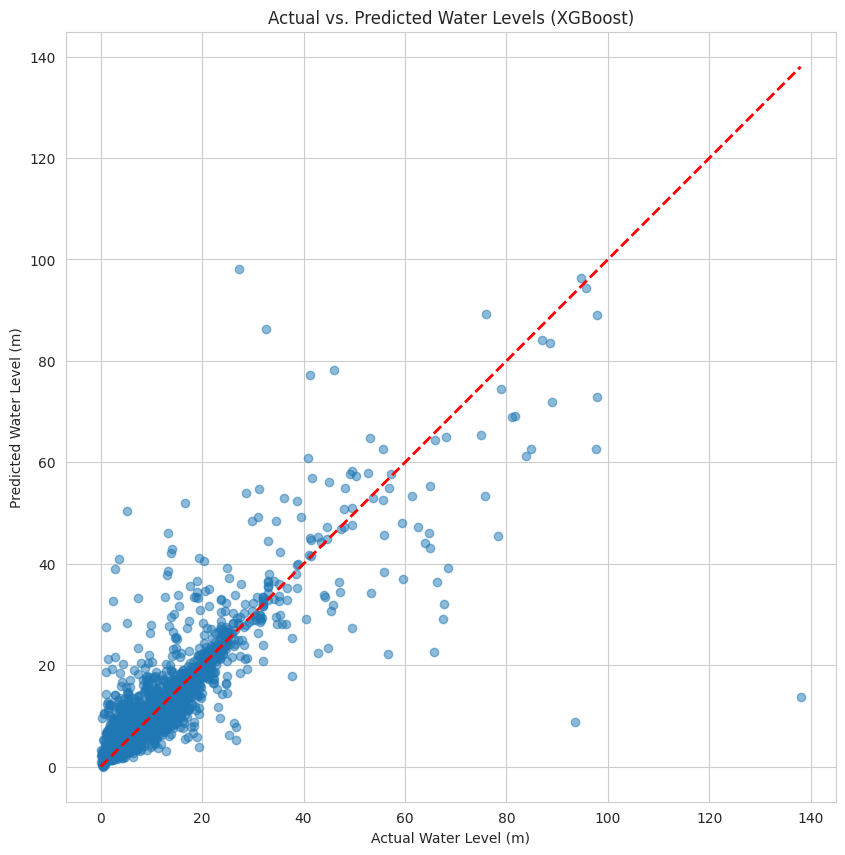

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Initialize and Train the XGBoost Model ---
print("--- Training XGBoost Model ---")
# n_estimators: The number of boosting rounds (trees) to build.
# learning_rate: Step size shrinkage to prevent overfitting. Lower is generally more robust.
# n_jobs=-1: Use all available CPU cores for speed.
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("Model training complete.")


# --- 2. Make Predictions and Evaluate ---
print("\n--- Evaluating XGBoost Model Performance ---")
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model R-squared (R²): {r2_xgb:.4f}")
print(f"XGBoost Model Mean Absolute Error (MAE): {mae_xgb:.4f} m")


# --- 3. Compare All Models ---
print("\n--- Final Model Performance Comparison ---")

# Ensure that mae and r2 from the baseline Random Forest model are available
# from the previous cell's execution context. If not, you would need to re-run
# the baseline model evaluation or pass these values.
# Assuming mae and r2 are available from the previous cell's successful execution:

# Create a DataFrame to compare the metrics
comparison_data = {
    'Model': ['Baseline Random Forest', 'XGBoost'],
    'R-squared (R²)': [r2, r2_xgb],
    'Mean Absolute Error (MAE)': [mae, mae_xgb]
}
comparison_df = pd.DataFrame(comparison_data).set_index('Model')

print(comparison_df)

# --- 4. Visualize XGBoost Results ---
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([0, y_test.max()], [0, y_test.max()], '--', color='red', lw=2)
plt.title('Actual vs. Predicted Water Levels (XGBoost)')
plt.xlabel('Actual Water Level (m)')
plt.ylabel('Predicted Water Level (m)')
plt.axis('equal')
plt.axis('square')
plt.show()

--- Generating a 12-month forecast for Well No: 63324 ---


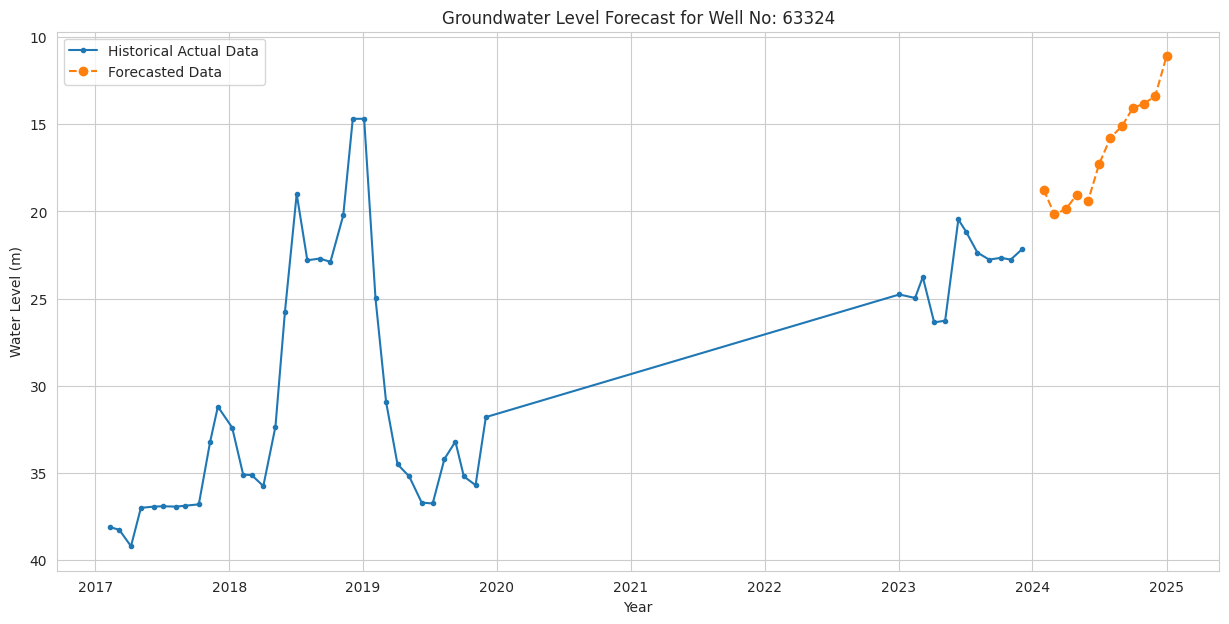

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Setup for Forecasting ---

# Choose a well to forecast. Let's pick one that has consistent data.
# You can change this to any Well No from your dataset.
well_to_forecast = '63324'

# The number of months we want to predict into the future
forecast_horizon = 12

# Use the best model we trained
final_model = xgb_model

# Isolate the historical data for just this well from our feature-engineered DataFrame
well_history_df = df_final[df_final['Well No'] == well_to_forecast].copy()

# Get the last known row of data for this well. This is our starting point.
last_known_data = well_history_df.iloc[[-1]]


# --- 2. Iterative Forecasting Loop ---
print(f"--- Generating a {forecast_horizon}-month forecast for Well No: {well_to_forecast} ---")

future_predictions = []

# Start with the last known data
current_data = last_known_data.copy()

for i in range(forecast_horizon):
    # Prepare the feature set for the next prediction
    X_future = current_data[features]

    # Predict the next month's water level
    next_prediction = final_model.predict(X_future)[0]
    future_predictions.append(next_prediction)

    # --- Update the data for the *next* loop iteration ---
    # Get the last date and advance it by one month
    last_date = current_data['date'].iloc[0]
    next_date = last_date + pd.DateOffset(months=1)

    # Create the next row of data using the prediction we just made
    next_row = current_data.copy()
    next_row['date'] = next_date
    next_row['year'] = next_date.year
    next_row['month'] = next_date.month

    # The crucial step: the new lag feature is the prediction we just made
    next_row['wl_lag_1'] = next_prediction

    # Update the rolling mean including the new prediction
    # For simplicity, we can do a rolling mean on the last few values we have
    previous_wls = list(current_data['Water Level (m)'].values) + future_predictions
    next_row['wl_rolling_mean_3'] = np.mean(previous_wls[-3:])

    # Set the 'current_data' for the next loop to be this new row
    current_data = next_row

# --- 3. Prepare Data for Plotting ---
# Create a DataFrame for the forecasted values
last_timestamp = last_known_data['date'].iloc[0]
future_dates = pd.date_range(start=last_timestamp, periods=forecast_horizon + 1, freq='MS')[1:]
forecast_df = pd.DataFrame({'date': future_dates, 'Forecasted Water Level (m)': future_predictions})
forecast_df.set_index('date', inplace=True)

# Set date as index for historical data for plotting
plot_history_df = well_history_df.set_index('date')


# --- 4. Visualize the Forecast ---
plt.figure(figsize=(15, 7))
plt.plot(plot_history_df['Water Level (m)'], label='Historical Actual Data', marker='.')
plt.plot(forecast_df['Forecasted Water Level (m)'], label='Forecasted Data', marker='o', linestyle='--')

plt.title(f'Groundwater Level Forecast for Well No: {well_to_forecast}')
plt.xlabel('Year')
plt.ylabel('Water Level (m)')
plt.legend()
plt.gca().invert_yaxis() # Invert y-axis for intuitive interpretation
plt.show()

In [ ]:
import pandas as pd
import re

# --- 1. Mount Google Drive and Load Data ---
from google.colab import drive
drive.mount('/content/drive')

# IMPORTANT: Adjust this path to match where you saved the file in your Google Drive.
file_path = '/content/drive/My Drive/Tiruppur_Data/Ground_Water_Quality.csv'

try:
    # Try reading with 'latin-1' encoding as UTF-8 failed
    df_quality = pd.read_csv(file_path, encoding='latin-1')
    print("File loaded successfully!")
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please check the path and file name.")
    # Stop execution if file is not found
    assert False, "File not found, stopping execution."
except UnicodeDecodeError:
    print(f"Error: Could not decode file with 'utf-8' or 'latin-1' encoding.")
    print("You might need to try a different encoding. You can try to detect the encoding using a library like 'chardet'.")
    assert False, "Encoding error, stopping execution."


# --- 2. Clean and Convert Data Types ---

# Convert 'Date of collection' to datetime objects
df_quality['Date of collection'] = pd.to_datetime(df_quality['Date of collection'], format='%d-%m-%Y')

# Convert 'RSC (meq/L)' to a numeric type, forcing errors to become NaN (missing)
df_quality['RSC (meq/L)'] = pd.to_numeric(df_quality['RSC (meq/L)'], errors='coerce')

# Define a function to convert DMS (Degrees, Minutes, Seconds) to Decimal Degrees
def dms_to_dd(dms):
    try:
        # Using regex to find numbers in the string
        parts = re.findall(r'\d+\.?\d*', dms)
        if len(parts) >= 2:
            degrees = float(parts[0])
            minutes = float(parts[1])
            seconds = float(parts[2]) if len(parts) > 2 else 0
            dd = degrees + minutes / 60 + seconds / 3600
            return dd
        return None
    except (TypeError, IndexError, ValueError):
        return None

# Apply the conversion function to Latitude and Longitude columns
print("\nConverting Latitude and Longitude to numeric format...")
df_quality['Latitude_DD'] = df_quality['Latitude'].apply(dms_to_dd)
df_quality['Longitude_DD'] = df_quality['Longitude'].apply(dms_to_dd)


# --- 3. Verify the Cleaned Data ---
print("\n--- Cleaned Data Info ---")
df_quality.info()

print("\n--- First 5 Rows of Cleaned Data ---")
# Displaying original and new coordinate columns for comparison
print(df_quality[[
    'Well No', 'Date of collection', 'TDS (mg/L)',
    'Latitude', 'Latitude_DD', 'Longitude', 'Longitude_DD'
]].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully!

Converting Latitude and Longitude to numeric format...

--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Well No             340 non-null    object        
 1   Well Type           340 non-null    object        
 2   District            340 non-null    object        
 3   Tahsil / Taluk      340 non-null    object        
 4   Village             340 non-null    object        
 5   Latitude            340 non-null    object        
 6   Longitude           340 non-null    object        
 7   Date of collection  340 non-null    datetime64[ns]
 8   TDS (mg/L)          340 non-null    int64         
 9   NO2+NO3 (mg/L)      340 non-null    

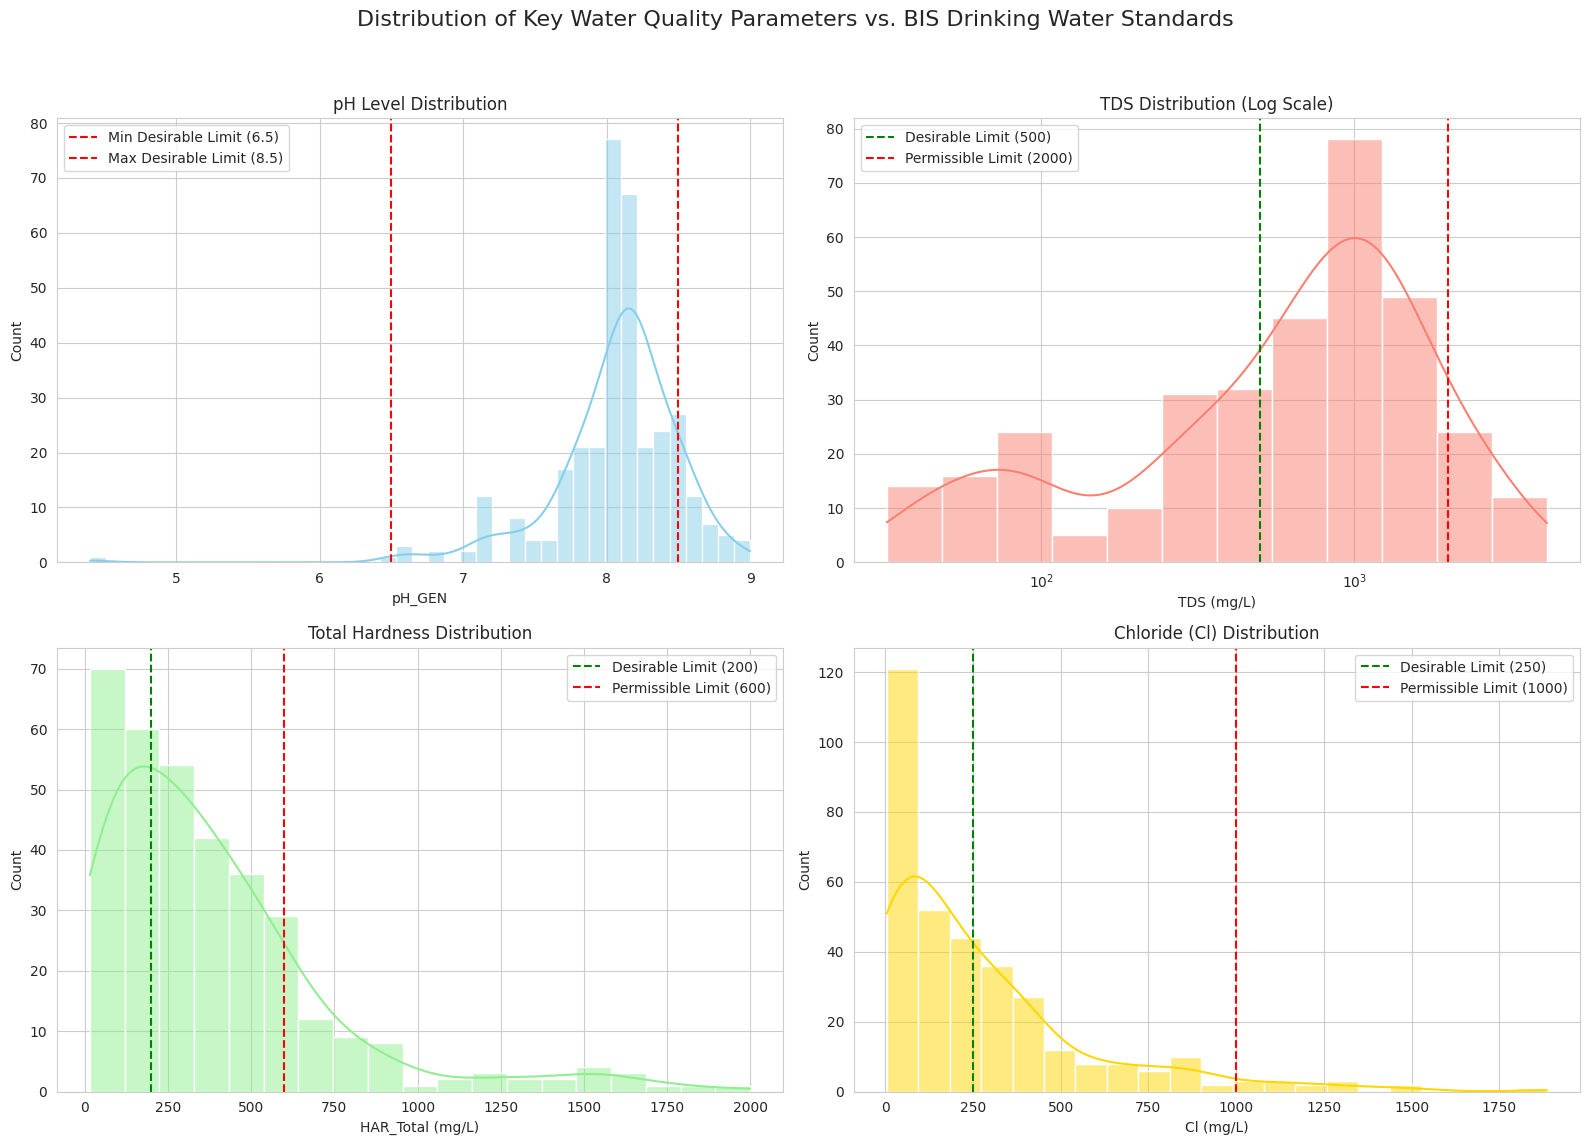

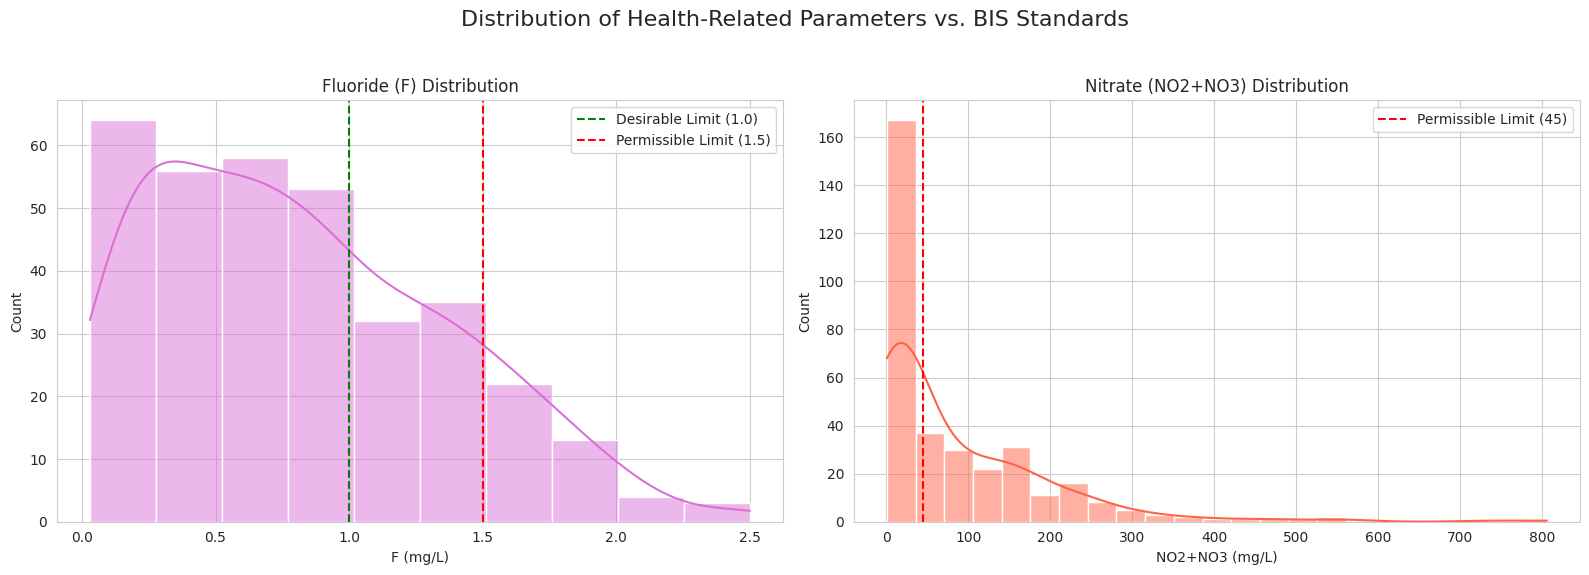

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# --- Plotting Basic & Salinity Parameters ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Water Quality Parameters vs. BIS Drinking Water Standards', fontsize=16)

# Plot 1: pH
sns.histplot(df_quality['pH_GEN'].dropna(), ax=axes[0, 0], kde=True, color='skyblue')
axes[0, 0].axvline(6.5, color='red', linestyle='--', label='Min Desirable Limit (6.5)')
axes[0, 0].axvline(8.5, color='red', linestyle='--', label='Max Desirable Limit (8.5)')
axes[0, 0].set_title('pH Level Distribution')
axes[0, 0].legend()

# Plot 2: Total Dissolved Solids (TDS)
sns.histplot(df_quality['TDS (mg/L)'].dropna(), ax=axes[0, 1], kde=True, color='salmon', log_scale=True)
axes[0, 1].axvline(500, color='green', linestyle='--', label='Desirable Limit (500)')
axes[0, 1].axvline(2000, color='red', linestyle='--', label='Permissible Limit (2000)')
axes[0, 1].set_title('TDS Distribution (Log Scale)')
axes[0, 1].legend()

# Plot 3: Total Hardness
sns.histplot(df_quality['HAR_Total (mg/L)'].dropna(), ax=axes[1, 0], kde=True, color='lightgreen')
axes[1, 0].axvline(200, color='green', linestyle='--', label='Desirable Limit (200)')
axes[1, 0].axvline(600, color='red', linestyle='--', label='Permissible Limit (600)')
axes[1, 0].set_title('Total Hardness Distribution')
axes[1, 0].legend()

# Plot 4: Chloride
sns.histplot(df_quality['Cl (mg/L)'].dropna(), ax=axes[1, 1], kde=True, color='gold')
axes[1, 1].axvline(250, color='green', linestyle='--', label='Desirable Limit (250)')
axes[1, 1].axvline(1000, color='red', linestyle='--', label='Permissible Limit (1000)')
axes[1, 1].set_title('Chloride (Cl) Distribution')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Plotting Health-Related Contaminants ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Health-Related Parameters vs. BIS Standards', fontsize=16)

# Plot 5: Fluoride (F)
sns.histplot(df_quality['F (mg/L)'].dropna(), ax=axes[0], kde=True, color='orchid')
axes[0].axvline(1.0, color='green', linestyle='--', label='Desirable Limit (1.0)')
axes[0].axvline(1.5, color='red', linestyle='--', label='Permissible Limit (1.5)')
axes[0].set_title('Fluoride (F) Distribution')
axes[0].legend()

# Plot 6: Nitrate (NO2+NO3)
sns.histplot(df_quality['NO2+NO3 (mg/L)'].dropna(), ax=axes[1], kde=True, color='tomato')
axes[1].axvline(45, color='red', linestyle='--', label='Permissible Limit (45)')
axes[1].set_title('Nitrate (NO2+NO3) Distribution')
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

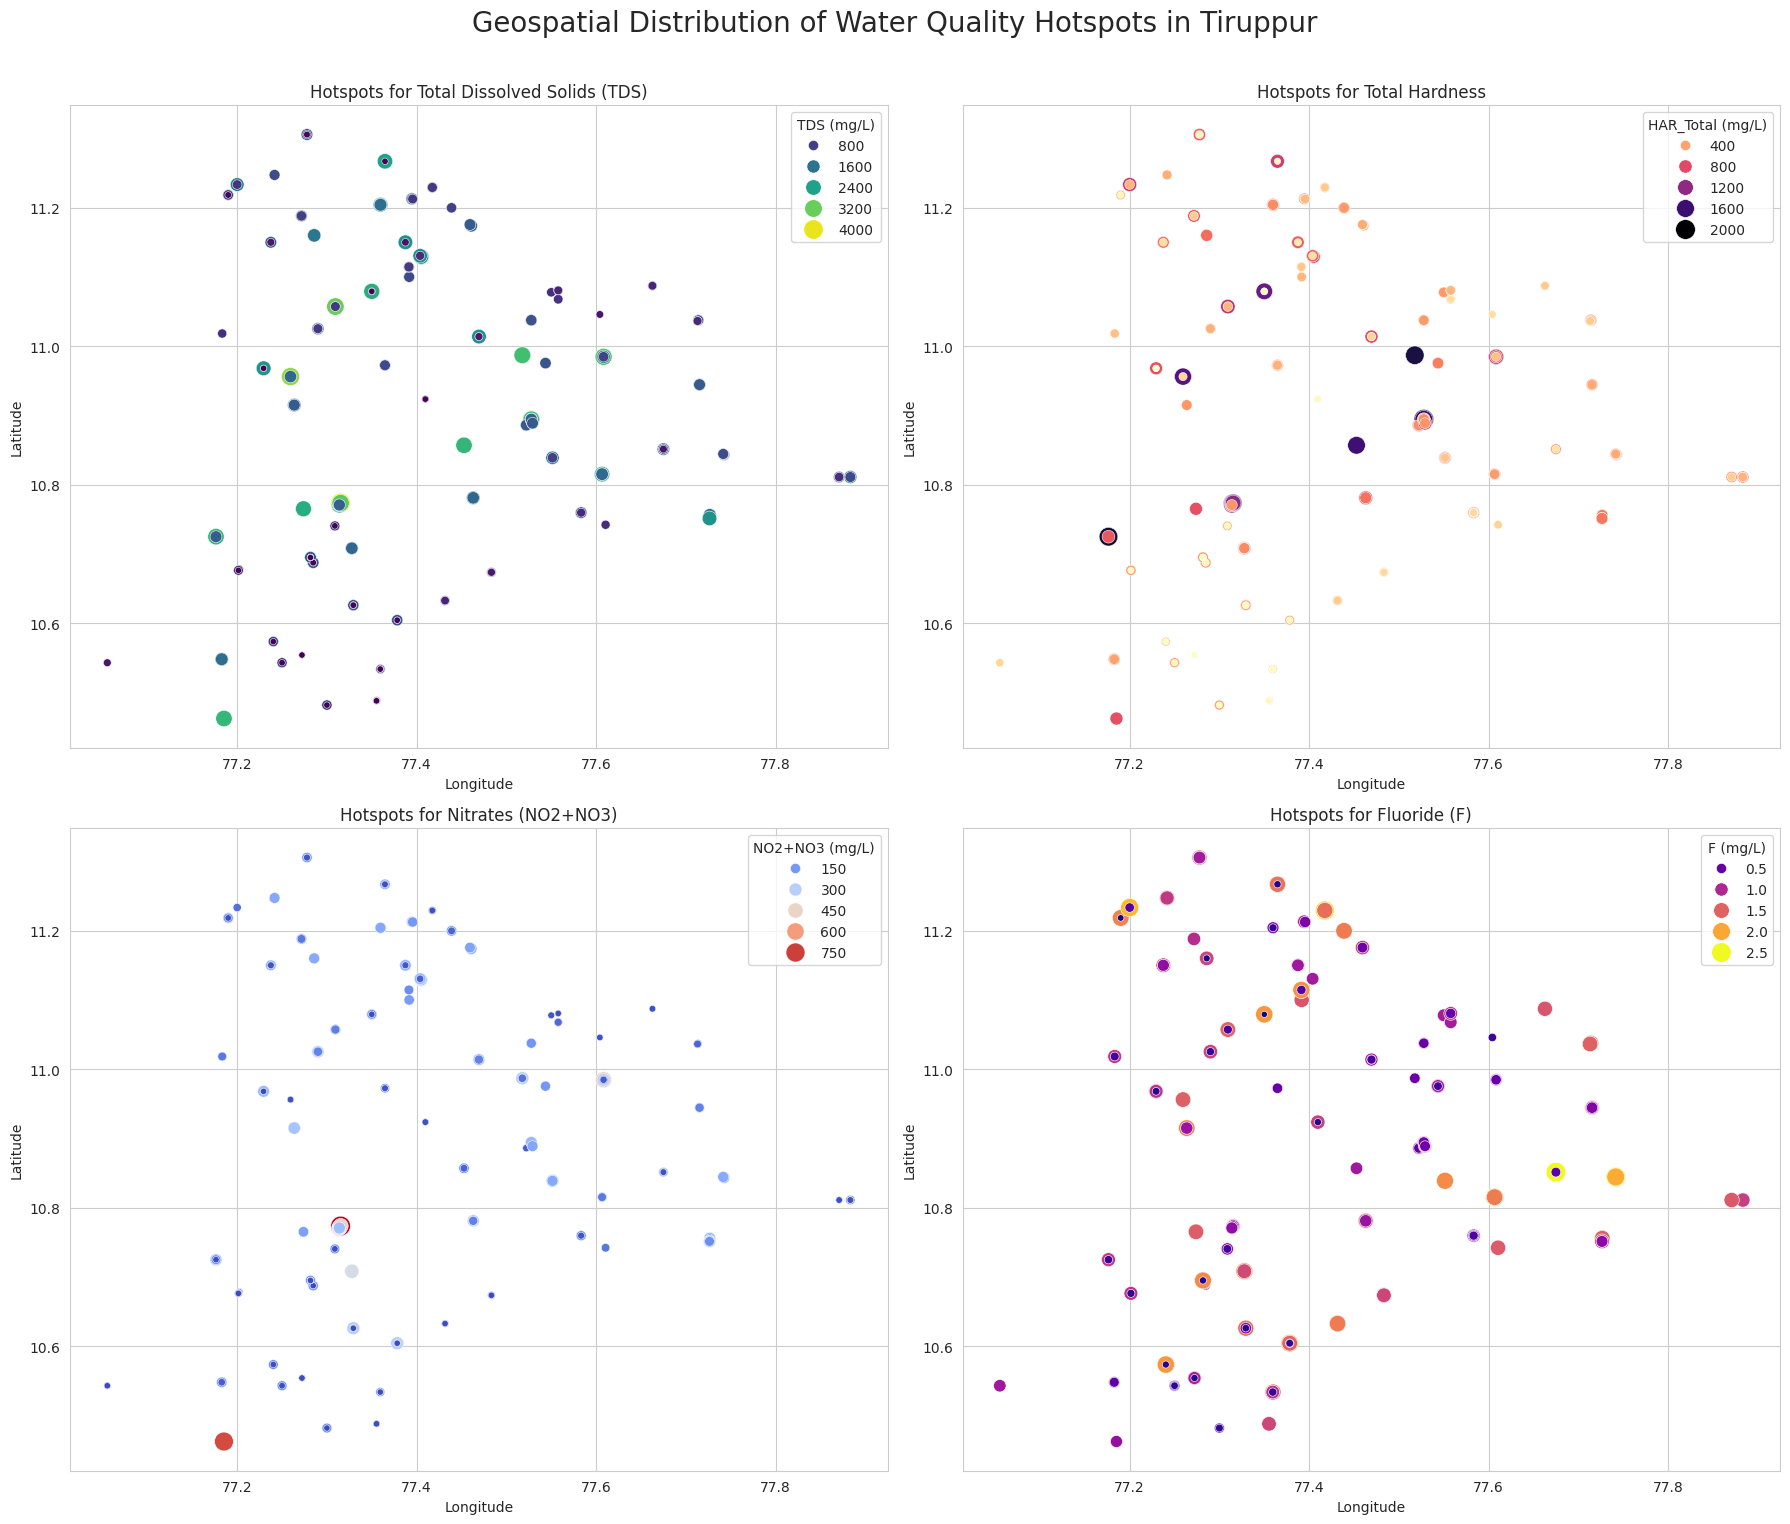

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will use the cleaned df_quality DataFrame from the previous step

# Create a 2x2 grid for our maps
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Geospatial Distribution of Water Quality Hotspots in Tiruppur', fontsize=20)

# --- Map 1: Total Dissolved Solids (TDS) ---
sns.scatterplot(data=df_quality, x='Longitude_DD', y='Latitude_DD', hue='TDS (mg/L)',
                palette='viridis', size='TDS (mg/L)', sizes=(20, 200), ax=axes[0, 0])
axes[0, 0].set_title('Hotspots for Total Dissolved Solids (TDS)')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# --- Map 2: Total Hardness ---
sns.scatterplot(data=df_quality, x='Longitude_DD', y='Latitude_DD', hue='HAR_Total (mg/L)',
                palette='magma_r', size='HAR_Total (mg/L)', sizes=(20, 200), ax=axes[0, 1])
axes[0, 1].set_title('Hotspots for Total Hardness')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# --- Map 3: Nitrates ---
sns.scatterplot(data=df_quality, x='Longitude_DD', y='Latitude_DD', hue='NO2+NO3 (mg/L)',
                palette='coolwarm', size='NO2+NO3 (mg/L)', sizes=(20, 200), ax=axes[1, 0])
axes[1, 0].set_title('Hotspots for Nitrates (NO2+NO3)')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# --- Map 4: Fluoride ---
sns.scatterplot(data=df_quality, x='Longitude_DD', y='Latitude_DD', hue='F (mg/L)',
                palette='plasma', size='F (mg/L)', sizes=(20, 200), ax=axes[1, 1])
axes[1, 1].set_title('Hotspots for Fluoride (F)')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Numeric columns selected for correlation analysis:
['TDS (mg/L)', 'NO2+NO3 (mg/L)', 'Ca (mg/L)', 'Mg (mg/L)', 'Na (mg/L)', 'K (mg/L)', 'Cl (mg/L)', 'SO4 (mg/L)', 'CO3 (mg/L)', 'HCO3 (mg/L)', 'F (mg/L)', 'pH_GEN', 'EC_GEN (µS/cm)', 'HAR_Total (mg/L)', 'SAR', 'RSC (meq/L)', 'Na%', 'Latitude_DD', 'Longitude_DD']


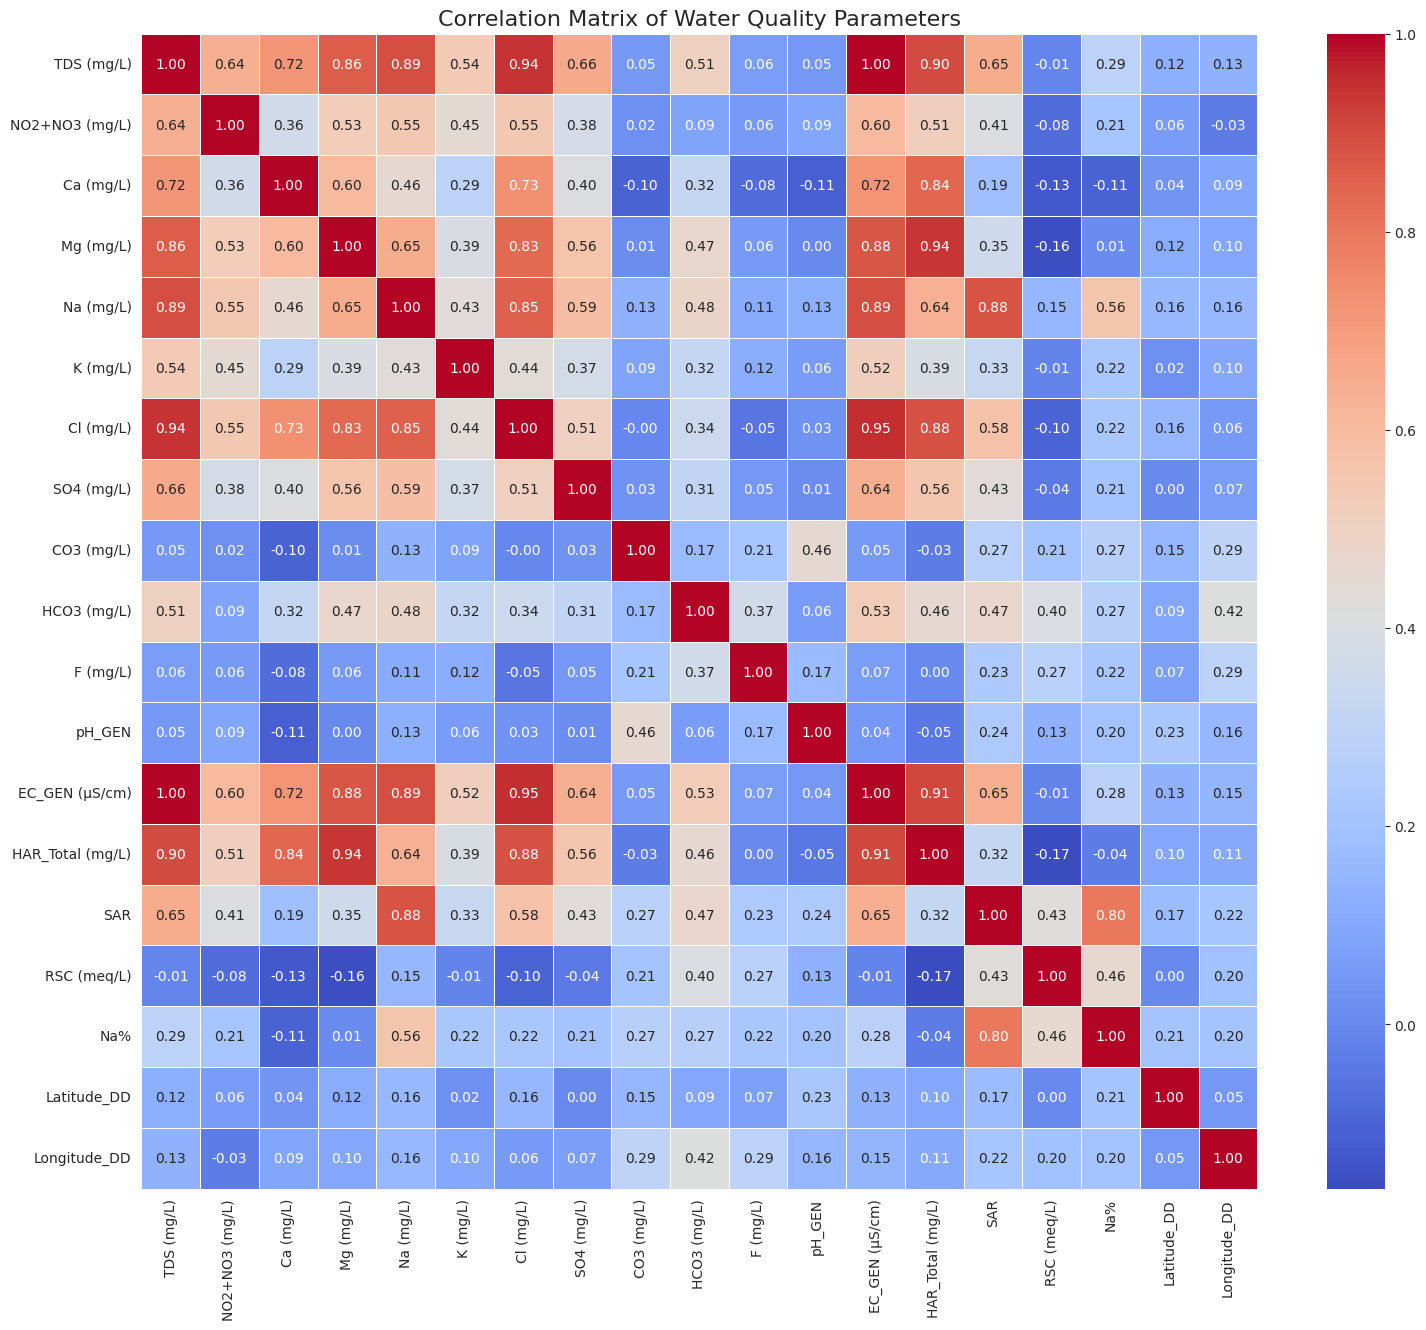

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Select only the numeric columns for correlation analysis ---
numeric_columns = df_quality.select_dtypes(include=['number']).columns
print("Numeric columns selected for correlation analysis:")
print(numeric_columns.tolist())

# --- 2. Calculate the correlation matrix ---
correlation_matrix = df_quality[numeric_columns].corr()

# --- 3. Visualize the correlation matrix as a heatmap ---
plt.figure(figsize=(18, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the correlation values on the map
    fmt='.2f',           # Format numbers to two decimal places
    cmap='coolwarm',     # Use a color scheme where red is positive and blue is negative
    linewidths=.5
)
plt.title('Correlation Matrix of Water Quality Parameters', fontsize=16)
plt.show()

--- Potability Classification ---
Potability
0    192
1    148
Name: count, dtype: int64

Training set has 168 samples.
Testing set has 72 samples.

--- Training the Classification Model ---
Model training complete.

--- Model Evaluation ---

Classification Report:
                 precision    recall  f1-score   support

Non-Potable (0)       1.00      0.95      0.97        38
    Potable (1)       0.94      1.00      0.97        34

       accuracy                           0.97        72
      macro avg       0.97      0.97      0.97        72
   weighted avg       0.97      0.97      0.97        72


Confusion Matrix:


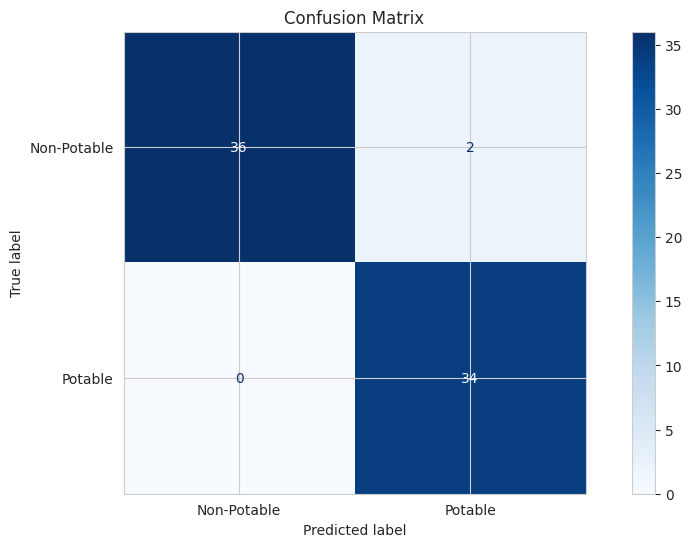

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Feature Engineering: Create the 'Potability' Target Variable ---

# Define a function to classify water based on BIS permissible limits
# Returns 1 for Potable, 0 for Non-Potable
def classify_potability(row):
    # BIS Permissible Limits (stricter 'desirable' limits could also be used)
    if (row['pH_GEN'] < 6.5 or row['pH_GEN'] > 8.5 or
        row['TDS (mg/L)'] > 2000 or
        row['Cl (mg/L)'] > 1000 or
        row['SO4 (mg/L)'] > 400 or # Sulfate limit
        row['NO2+NO3 (mg/L)'] > 45 or
        row['F (mg/L)'] > 1.5):
        return 0  # Non-Potable
    else:
        return 1  # Potable

# Apply the function to create the new target column
df_quality['Potability'] = df_quality.apply(classify_potability, axis=1)

print("--- Potability Classification ---")
print(df_quality['Potability'].value_counts())


# --- 2. Define Features (X) and Target (y) ---
# We drop rows with any missing values to ensure the model can train
df_clean = df_quality.dropna()

# The features are the chemical measurements
features = [
    'TDS (mg/L)', 'NO2+NO3 (mg/L)', 'Ca (mg/L)', 'Mg (mg/L)', 'Na (mg/L)',
    'K (mg/L)', 'Cl (mg/L)', 'SO4 (mg/L)', 'HCO3 (mg/L)', 'F (mg/L)', 'pH_GEN',
    'EC_GEN (µS/cm)', 'HAR_Total (mg/L)', 'SAR', 'RSC (meq/L)', 'Na%'
]
X = df_clean[features]
y = df_clean['Potability']


# --- 3. Split Data into Training and Testing Sets ---
# stratify=y ensures the proportion of Potable/Non-Potable samples is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTraining set has {X_train.shape[0]} samples.")
print(f"Testing set has {X_test.shape[0]} samples.")


# --- 4. Train the RandomForestClassifier Model ---
print("\n--- Training the Classification Model ---")
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train)
print("Model training complete.")


# --- 5. Evaluate the Model's Performance ---
print("\n--- Model Evaluation ---")
y_pred = classifier.predict(X_test)

# Print the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Potable (0)', 'Potable (1)']))

# Display the Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Potable', 'Potable'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Mounted at /content/drive


/tmp/ipython-input-3883842518.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_rain['value'].resample('M').sum().to_frame()


--- Monthly Aggregated Data (Last 5 Months) ---
            Rainfall_mm
date                   
2023-08-31        413.8
2023-09-30        523.9
2023-10-31       2258.4
2023-11-30       3490.4
2023-12-31        858.2


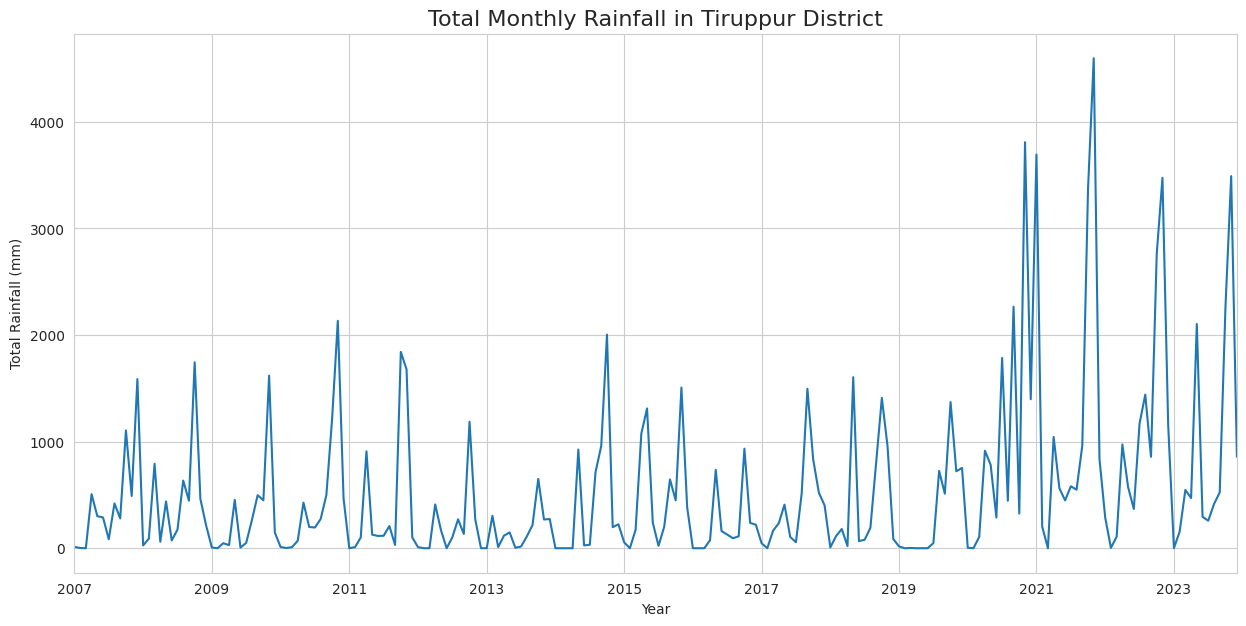

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from google.colab import drive

# Set plotting styles for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

# --- 1. Load and Clean Data ---
# We assume df_rain is already loaded from the previous step.
# If not, you would load it here:
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Tiruppur_Data/Tiruppur_RFD.csv'
df_rain = pd.read_csv(file_path)

df_rain['date'] = pd.to_datetime(df_rain['date'], format='%d-%m-%Y')


# --- 2. Aggregate to Monthly Rainfall ---
# We group all station data together to get a district-level overview.
# First, set the date as the index.
df_rain.set_index('date', inplace=True)

# Resample the data by month ('M') and sum the values to get total monthly rainfall.
df_monthly = df_rain['value'].resample('M').sum().to_frame()
df_monthly.rename(columns={'value': 'Rainfall_mm'}, inplace=True)

print("--- Monthly Aggregated Data (Last 5 Months) ---")
print(df_monthly.tail())


# --- 3. Plot the Monthly Time Series ---
df_monthly['Rainfall_mm'].plot()
plt.title('Total Monthly Rainfall in Tiruppur District', fontsize=16)
plt.ylabel('Total Rainfall (mm)')
plt.xlabel('Year')
plt.show()

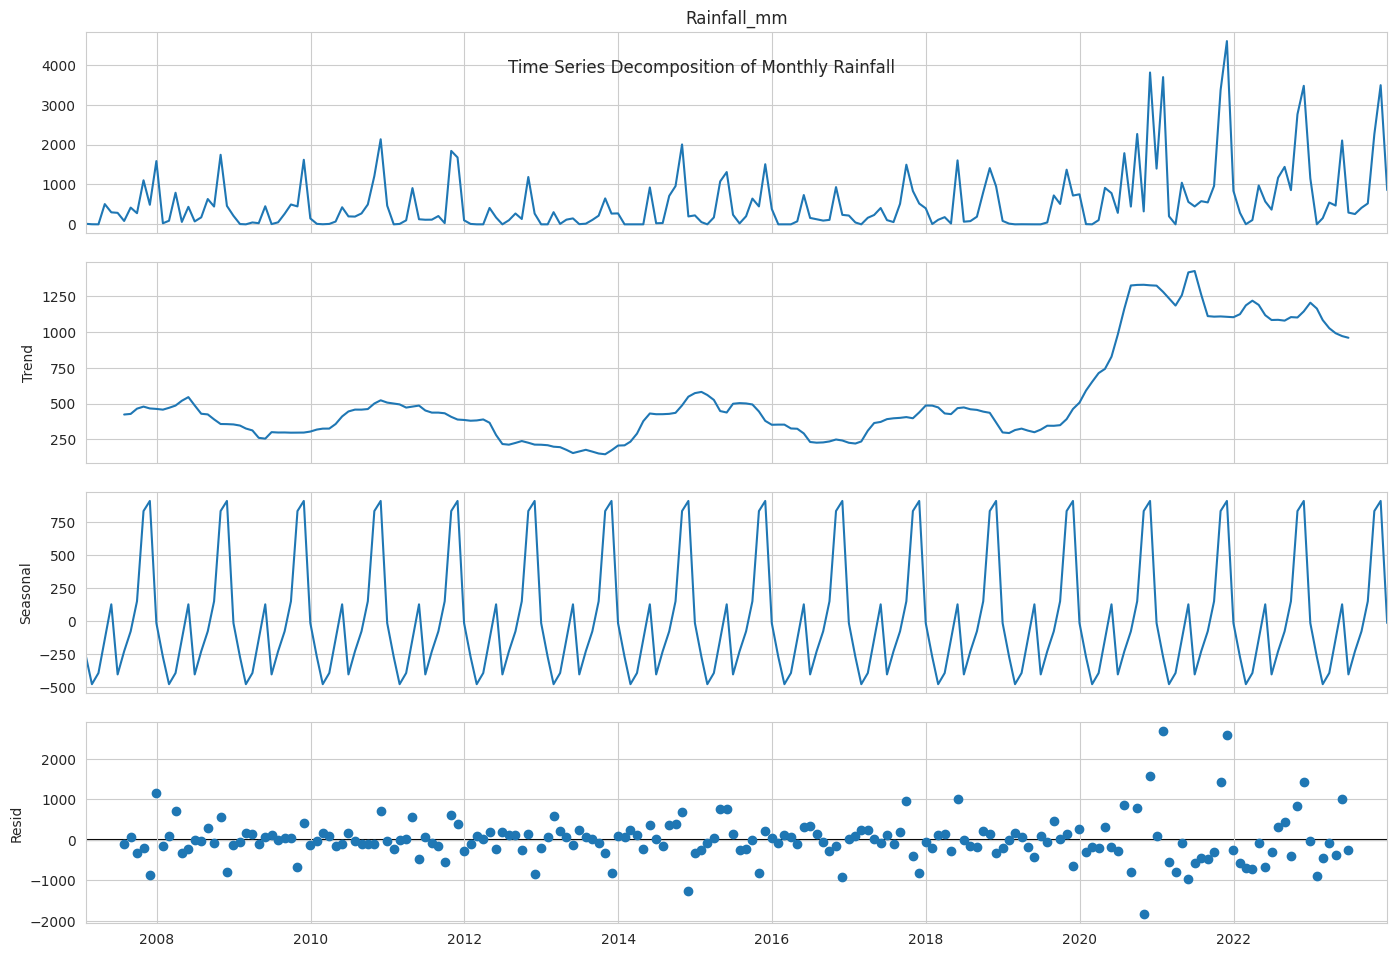

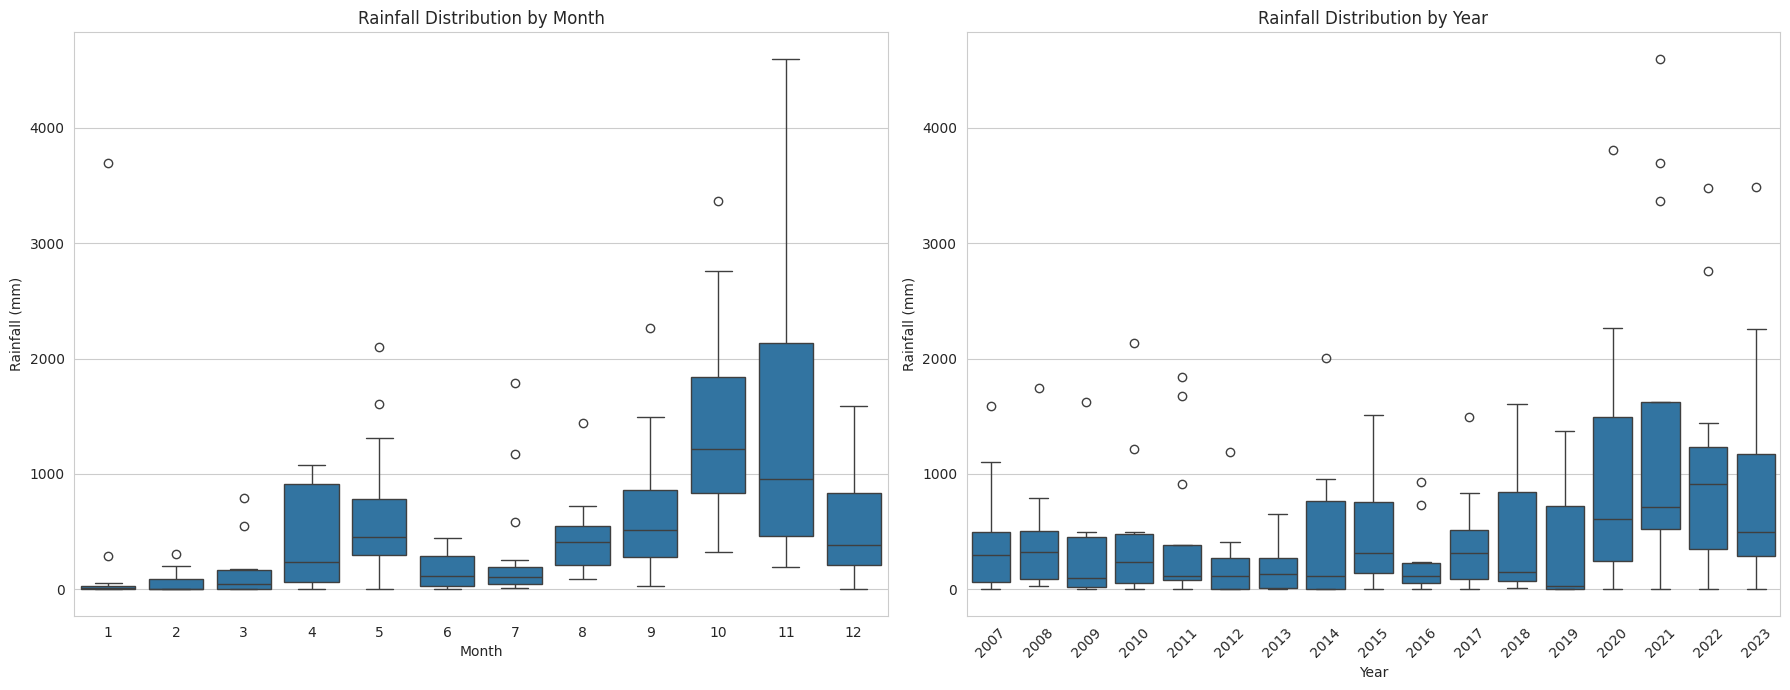

In [ ]:
# --- 4. Time Series Decomposition ---
# Decompose the series to see the trend, seasonality, and residual components.
decomposition = seasonal_decompose(df_monthly['Rainfall_mm'], model='additive')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition of Monthly Rainfall', y=0.92)
plt.show()


# --- 5. Visualize Monthly and Yearly Distributions ---
# Add month and year columns for easier grouping
df_monthly['month'] = df_monthly.index.month
df_monthly['year'] = df_monthly.index.year

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot of rainfall for each month to see seasonality
sns.boxplot(ax=axes[0], data=df_monthly, x='month', y='Rainfall_mm')
axes[0].set_title('Rainfall Distribution by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Rainfall (mm)')

# Boxplot of rainfall for each year to see yearly variations
sns.boxplot(ax=axes[1], data=df_monthly, x='year', y='Rainfall_mm')
axes[1].set_title('Rainfall Distribution by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


--- Building the LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

None

--- Training the LSTM Model (this may take a minute)... ---
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


168/168 - 3s - 17ms/step - loss: 0.0244
Epoch 2/50
168/168 - 1s - 3ms/step - loss: 0.0241
Epoch 3/50
168/168 - 0s - 3ms/step - loss: 0.0234
Epoch 4/50
168/168 - 1s - 3ms/step - loss: 0.0217
Epoch 5/50
168/168 - 1s - 3ms/step - loss: 0.0228
Epoch 6/50
168/168 - 0s - 3ms/step - loss: 0.0223
Epoch 7/50
168/168 - 0s - 3ms/step - loss: 0.0228
Epoch 8/50
168/168 - 1s - 3ms/step - loss: 0.0228
Epoch 9/50
168/168 - 1s - 3ms/step - loss: 0.0214
Epoch 10/50
168/168 - 1s - 3ms/step - loss: 0.0202
Epoch 11/50
168/168 - 1s - 4ms/step - loss: 0.0227
Epoch 12/50
168/168 - 1s - 3ms/step - loss: 0.0213
Epoch 13/50
168/168 - 0s - 3ms/step - loss: 0.0297
Epoch 14/50
168/168 - 1s - 3ms/step - loss: 0.0241
Epoch 15/50
168/168 - 1s - 3ms/step - loss: 0.0242
Epoch 16/50
168/168 - 1s - 4ms/step - loss: 0.0238
Epoch 17/50
168/168 - 1s - 4ms/step - loss: 0.0233
Epoch 18/50
168/168 - 1s - 4ms/step - loss: 0.0225
Epoch 19/50
168/168 - 1s - 4ms/step - loss: 0.0220
Epoch 20/50
168/168 - 1s - 7ms/step - loss: 0.0215

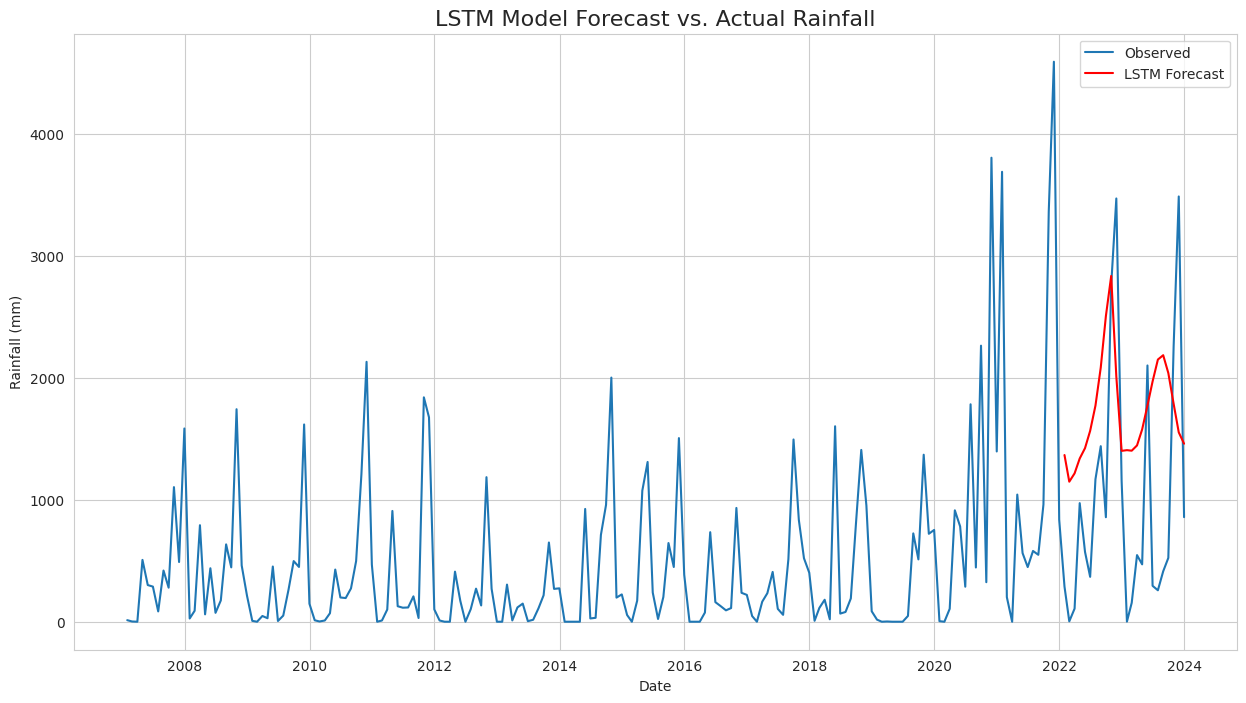

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
tf.random.set_seed(42)

# --- 1. Data Preparation for LSTM ---

# Use the same training and testing data splits as before
train_data = df_monthly['Rainfall_mm'][:'2021-12-31'].values.reshape(-1, 1)
test_data = df_monthly['Rainfall_mm']['2022-01-01':].values.reshape(-1, 1)

# Scale the data to be between 0 and 1
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit ONLY on training data to avoid data leakage

scaled_train = scaler.transform(train_data)
scaled_test = scaler.transform(test_data)

# Create sequences of data (e.g., use the last 12 months to predict the next month)
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
look_back = 12 # This is our sequence length
train_generator = TimeseriesGenerator(scaled_train, scaled_train, length=look_back, batch_size=1)


# --- 2. Build and Compile the LSTM Model ---
print("\n--- Building the LSTM Model ---")
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

print(model_lstm.summary())


# --- 3. Train the Model ---
print("\n--- Training the LSTM Model (this may take a minute)... ---")
model_lstm.fit(train_generator, epochs=50, verbose=2)


# --- 4. Make Predictions (Iterative Forecasting) ---
print("\n--- Generating forecasts on the test set ---")
# Start with the last 'look_back' months of the training data
last_train_batch = scaled_train[-look_back:]
current_batch = last_train_batch.reshape((1, look_back, 1))

test_predictions = []

for i in range(len(test_data)):
    # Get the prediction value for the first batch
    current_pred = model_lstm.predict(current_batch, verbose=0)[0]

    # Append the prediction
    test_predictions.append(current_pred)

    # Update the batch to now include the prediction and drop the first value
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

# --- 5. Inverse Transform and Evaluate ---
# Rescale the predictions back to the original rainfall values (mm)
actual_predictions = scaler.inverse_transform(test_predictions)

mae_lstm = mean_absolute_error(test_data, actual_predictions)
print(f"\nLSTM Model Mean Absolute Error (MAE): {mae_lstm:.2f} mm")


# --- 6. Visualize the Forecast vs. Actual Data ---
# Create a date index for our predictions
pred_index = df_monthly['2022-01-01':].index

plt.figure(figsize=(15, 8))
plt.plot(df_monthly['Rainfall_mm'], label='Observed') # Corrected variable name
plt.plot(pred_index, actual_predictions, label='LSTM Forecast', color='red')
plt.title('LSTM Model Forecast vs. Actual Rainfall', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()